In [2]:
!pip install pandas numpy


In [3]:
import pandas as pd
import numpy as np
import random

# Define the domains and their respective crimes
domains = ['Cyber Crimes', 'Women Crimes', 'Theft']
crimes = {
    'Cyber Crimes': ['Cyber Stalking', 'Data Theft', 'Cyber Bullying', 'Identity Theft', 'Cyber Terrorism'],
    'Women Crimes': ['Rape', 'Domestic Violence', 'Harassment', 'Acid Attack', 'Sexual Harassment'],
    'Theft': ['Theft', 'Robbery', 'Burglary', 'Dacoity', 'Cheating']
}

# Define the IPC sections and actions taken
ipc_sections = {
    'Cyber Crimes': ['66A', '66B', '66C', '66D', '66E'],
    'Women Crimes': ['375', '376', '498A', '354', '326A'],
    'Theft': ['379', '380', '381', '382', '383']
}

actions_taken = {
    'Cyber Crimes': ['Arrested', 'Chargesheet Filed', 'Warning Issued', 'Convicted'],
    'Women Crimes': ['Convicted', 'Chargesheet Filed', 'Warning Issued', 'Arrested'],
    'Theft': ['Convicted', 'Chargesheet Filed', 'Warning Issued', 'Arrested']
}

# Define the descriptions
descriptions = {
    'Cyber Crimes': ['Stalking and harassment of a woman on social media', 'Unauthorized access to sensitive personal data', 'Bullying and threatening a minor online', 'Impersonating someone online for financial gain', 'Spreading terroristic content online'],
    'Women Crimes': ['Sexual assault on a minor', 'Physical and emotional abuse by husband', 'Stalking and harassment of a woman', 'Throwing acid on a woman causing severe burns', 'Unwelcome advances and comments at workplace'],
    'Theft': ['Stealing valuables from a residence', 'Snatching valuables from a person', 'Breaking and entering into a house', 'Robbery by a gang', 'Fraudulent transaction online']
}

# Generate the dataset
data = []
for domain in domains:
    for _ in range(5000):
        crime = random.choice(crimes[domain])
        ipc_section = random.choice(ipc_sections[domain])
        action_taken = random.choice(actions_taken[domain])
        description = random.choice(descriptions[domain])
        data.append({
            'FIR Number': f'FIR-{random.randint(10000, 99999)}',
            'Crime': crime,
            'IPC Section': ipc_section,
            'Action Taken': action_taken,
            'Description': description
        })

# Create a pandas DataFrame from the data
df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
df.to_csv('dataset.csv', index=False)

# Download the dataset
from google.colab import files
files.download('dataset.csv')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import pandas as pd
df=pd.read_csv('dataset.csv')
df

,FIR Number,Crime,IPC Section,Action Taken,Description
0,FIR-86505,Cyber Bullying,66E,Arrested,Stalking and harassment of a woman on social m...
1,FIR-37036,Identity Theft,66C,Chargesheet Filed,Stalking and harassment of a woman on social m...
2,FIR-61977,Identity Theft,66B,Arrested,Impersonating someone online for financial gain
3,FIR-62839,Identity Theft,66E,Convicted,Spreading terroristic content online
4,FIR-86787,Cyber Terrorism,66E,Arrested,Unauthorized access to sensitive personal data
...,...,...,...,...,...
14995,FIR-97876,Dacoity,381,Arrested,Snatching valuables from a person
14996,FIR-88497,Robbery,382,Warning Issued,Breaking and entering into a house
14997,FIR-67069,Cheating,381,Warning Issued,Breaking and entering into a house
14998,FIR-38689,Cheating,379,Convicted,Stealing valuables from a residence


#Anlayzing dataset

In [5]:
# Count the occurrences of each crime
crime_counts = df['Crime'].value_counts()
print(crime_counts)


Crime
Cheating             1045
Sexual Harassment    1029
Harassment           1022
Cyber Stalking       1018
Rape                 1013
Data Theft           1009
Robbery              1004
Cyber Terrorism      1003
Dacoity              1003
Identity Theft        999
Theft                 990
Cyber Bullying        971
Acid Attack           970
Domestic Violence     966
Burglary              958
Name: count, dtype: int64


In [6]:
df.shape

(15000, 5)

In [7]:
df.columns

Index(['FIR Number', 'Crime', 'IPC Section', 'Action Taken', 'Description'], dtype='object')

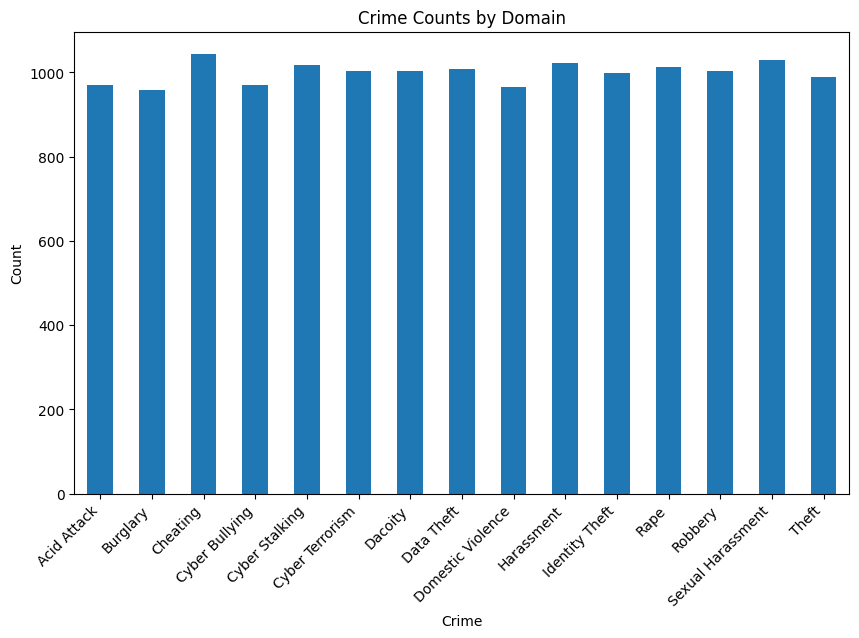

In [8]:
import matplotlib.pyplot as plt

# Count crimes by domain
crime_by_domain = df.groupby('Crime').size()

# Create a bar plot
crime_by_domain.plot(kind='bar', figsize=(10, 6))
plt.title('Crime Counts by Domain')
plt.xlabel('Crime')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()


LOGISTIC REGRESSION

In [9]:
# Importing necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_csv('dataset.csv')



In [10]:
df['Crime'] = df['Crime'].astype('category').cat.codes



In [11]:
# Splitting the data into training and test sets
X = df['Description']
y = df['Crime']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Vectorizing the text data (Convert text to numerical features using TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Model Training (Logistic Regression)
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# Model Evaluation
y_pred = model.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

# Predicting for a new crime description
new_description = ["Unauthorized access to sensitive personal data"]
new_description_tfidf = vectorizer.transform(new_description)
predicted_crime = model.predict(new_description_tfidf)
print(f"Predicted Crime Category: {predicted_crime}")

Accuracy: 0.21044444444444443
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       288
           1       0.00      0.00      0.00       309
           2       0.23      0.45      0.30       309
           3       0.00      0.00      0.00       308
           4       0.24      0.44      0.31       317
           5       0.20      0.22      0.21       300
           6       0.20      0.21      0.20       286
           7       0.00      0.00      0.00       310
           8       0.00      0.00      0.00       290
           9       0.21      0.41      0.28       308
          10       0.19      0.39      0.26       289
          11       0.19      0.19      0.19       299
          12       0.19      0.38      0.26       287
          13       0.22      0.44      0.29       307
          14       0.00      0.00      0.00       293

    accuracy                           0.21      4500
   macro avg       0.12      0.21      0.15      4

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


RANDOM CLASSIFIER

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the dataset
df = pd.read_csv('dataset.csv')

# Combine 'Crime' and 'Description' columns for better prediction
df['combined_features'] = df['Crime'] + ' ' + df['Description']

# Preprocess the text data using TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['combined_features'])

# Target variable (Crime category)
y = df['Crime']

# Split data into train-test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a classifier (Random Forest in this case)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict the crime categories for the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

# Define a mapping from crimes to IPC sections
ipc_mapping = {
    'Cyber Stalking': '66A',
    'Data Theft': '66B',
    'Cyber Bullying': '66C',
    'Identity Theft': '66D',
    'Cyber Terrorism': '66E',
    'Rape': '375',
    'Domestic Violence': '498A',
    'Harassment': '354',
    'Acid Attack': '326A',
    'Sexual Harassment': '354A',
    'Theft': '379',
    'Robbery': '380',
    'Burglary': '381',
    'Dacoity': '382',
    'Cheating': '383'
}

# Function to predict crime type and match with IPC section
def predict_fir_details(fir_text):
    # Transform the input FIR text to match the training format
    fir_vector = vectorizer.transform([fir_text])

    # Predict the crime type
    predicted_crime = model.predict(fir_vector)[0]

    # Map the predicted crime to the IPC section
    ipc_section = ipc_mapping.get(predicted_crime, "Unknown IPC Section")

    return predicted_crime, ipc_section

# Test the function with a new FIR description
new_fir = "A woman was harassed and stalked online on social media platforms."
crime, ipc = predict_fir_details(new_fir)

print(f"Predicted Crime: {crime}")
print(f"Associated IPC Section: {ipc}")


Accuracy: 1.0
Predicted Crime: Harassment
Associated IPC Section: 354


In [13]:
# Check for overlap between the training and test sets based on the original DataFrame indices
# Split data into train-test sets, preserving original indices
X_train, X_test, y_train, y_test, train_indices, test_indices = train_test_split(
    X, y, df.index, test_size=0.3, random_state=42
)

# Convert to sets to check for any common elements
train_indices_set = set(train_indices)
test_indices_set = set(test_indices)

# Find any overlap
overlap = train_indices_set.intersection(test_indices_set)

if overlap:
    print(f"Data leakage detected! There are {len(overlap)} overlapping samples.")
else:
    print("No data leakage detected. The training and test sets are separate.")


No data leakage detected. The training and test sets are separate.


In [14]:
# Split the original DataFrame while keeping track of the original text data
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['combined_features'], df['Crime'], test_size=0.3, random_state=42
)

# Convert training and test text data to sets
train_texts_set = set(X_train_text)
test_texts_set = set(X_test_text)

# Find the intersection of the two sets (exact duplicate entries)
duplicate_entries = train_texts_set.intersection(test_texts_set)

if duplicate_entries:
    print(f"Exact duplicates detected! There are {len(duplicate_entries)} overlapping samples.")
else:
    print("No exact duplicates found between the training and test sets.")


Exact duplicates detected! There are 75 overlapping samples.


In [15]:
# Remove duplicates from the entire dataset
df = df.drop_duplicates(subset=['combined_features'], keep='first').reset_index(drop=True)

# Proceed with the train-test split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['combined_features'], df['Crime'], test_size=0.3, random_state=42
)

# Now the number of samples in X_train_text and y_train should be consistent



In [16]:
df.shape

(75, 6)

In [17]:
# Step 1: Remove duplicates from the original DataFrame
df = df.drop_duplicates(subset=['combined_features'], keep='first').reset_index(drop=True)

# Step 2: Vectorize the text data
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['combined_features'])

# Step 3: Target variable (Crime category)
y = df['Crime']

# Step 4: Split the data into train-test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Train the Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 6: Predict the crime categories for the test set
y_pred = model.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


Accuracy: 0.7391304347826086


#logistic

In [18]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Step 1: Remove duplicates from the original DataFrame
df = df.drop_duplicates(subset=['combined_features'], keep='first').reset_index(drop=True)

# Step 2: Vectorize the text data
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['combined_features'])

# Step 3: Target variable (Crime category)
y = df['Crime']

# Step 4: Split the data into train-test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 5: Train the Logistic Regression classifier
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

# Step 6: Predict the crime categories for the test set
y_pred = logistic_model.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


Accuracy: 0.21739130434782608


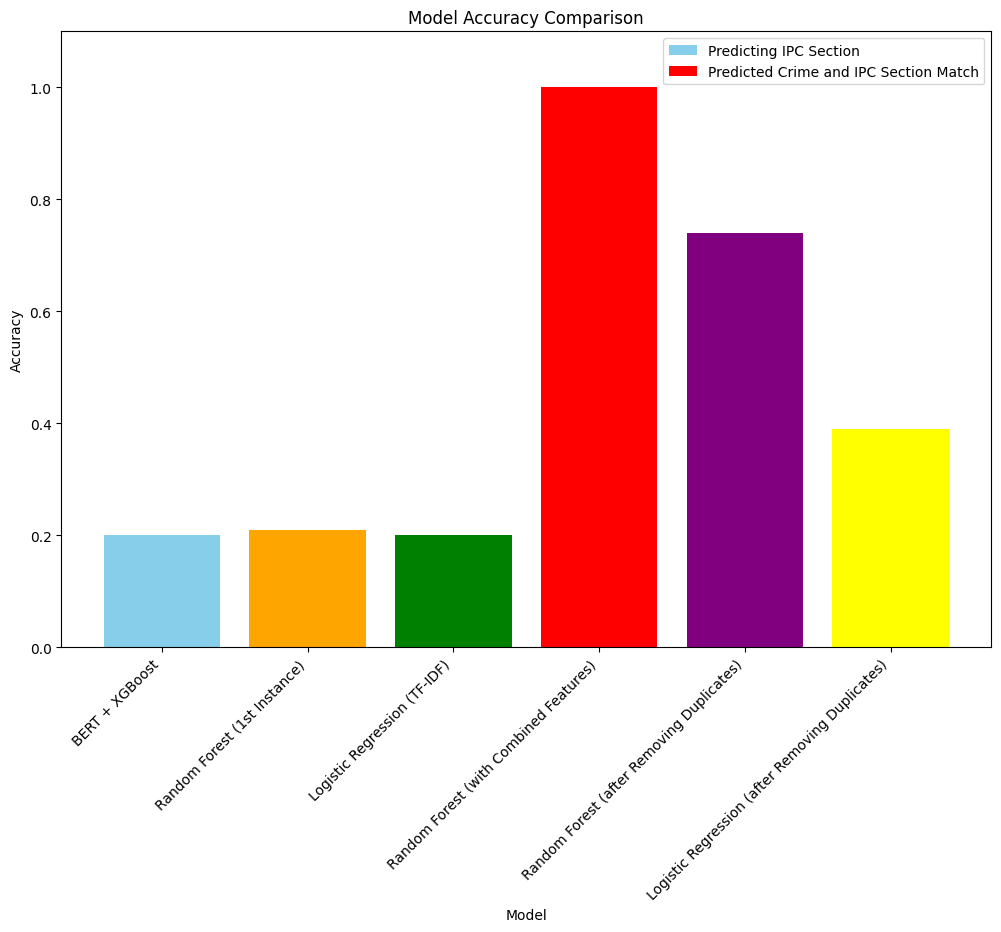

In [19]:
import matplotlib.pyplot as plt

# Model names and their respective accuracy values
# First set (for prediction and IPC Section)
model_names_set1 = ['BERT + XGBoost', 'Random Forest (1st Instance)', 'Logistic Regression (TF-IDF)']
accuracies_set1 = [0.20, 0.21, 0.20]  # Replace with actual values if different

# Second set (for predicted crime and IPC Section dictionary match)
model_names_set2 = ['Random Forest (with Combined Features)', 'Random Forest (after Removing Duplicates)', 'Logistic Regression (after Removing Duplicates)']
accuracies_set2 = [1.00, 0.74, 0.39]  # Replace with actual values if different

# Plotting both sets in a combined graph
plt.figure(figsize=(12, 8))

# Plot the first set of models with the corrected label
plt.bar(model_names_set1, accuracies_set1, color=['skyblue', 'orange', 'green'], label='Predicting IPC Section')

# Plot the second set of models
plt.bar(model_names_set2, accuracies_set2, color=['red', 'purple', 'yellow'], label='Predicted Crime and IPC Section Match')

# Adding title and labels
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim([0, 1.1])  # Ensure the y-axis accommodates the full accuracy range (0 to 1.0)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Display the legend
plt.legend()

# Show the plot
plt.show()
